In [95]:
! pip3 install torch 
# torch is working with tensors - 4+
# dimensional matrices

import pandas as pd
import torch

diabetes_df = pd.read_csv("../week_06/diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [96]:
from sklearn.model_selection import train_test_split

X = diabetes_df.drop('Outcome', axis=1).values
y = diabetes_df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

In [97]:
import torch.nn as nn
import torch.nn.functional as F # functional has the activation functions

#create tensors from the data
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_test = torch.LongTensor(y_test)
y_train = torch.LongTensor(y_train)

print(X_train)


tensor([[  7.0000, 184.0000,  84.0000,  ...,  35.5000,   0.3550,  41.0000],
        [  6.0000,  85.0000,  78.0000,  ...,  31.2000,   0.3820,  42.0000],
        [  2.0000, 106.0000,  64.0000,  ...,  30.5000,   1.4000,  34.0000],
        ...,
        [  1.0000,  97.0000,  70.0000,  ...,  38.1000,   0.2180,  30.0000],
        [  6.0000, 190.0000,  92.0000,  ...,  35.5000,   0.2780,  66.0000],
        [  4.0000, 144.0000,  58.0000,  ...,  29.5000,   0.2870,  37.0000]])


In [98]:
# artificial neural network
class ANN_Model(nn.Module):
    def __init__(self,input_features=8,
                 hidden1=20,hidden2=20,
                 out_features=2):
        super().__init__() 
        """
        super is a computed indirect reference
        which means that it isolates changes and
        makes sure the children in the layers of
        multiple inheritance are calling 
        the right parents
        """
        self.layer_1_connection = nn.Linear(input_features, hidden1)
        self.layer_2_connection = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)

    def forward(self, x):
        #apply activation function
        x = F.relu(self.layer_1_connection(x))
        x = F.relu(self.layer_2_connection(x))
        x = self.out(x)
        return x

In [99]:
torch.manual_seed(42)

# create an instance of the model
ann = ANN_Model()

In [100]:
# loss function 
loss_function = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(ann.parameters(), lr = 0.01)


In [101]:
# run model through various epochs/iterations
final_loss = []
n_epochs = 500
for epoch in range(n_epochs):
    y_pred = ann.forward(X_train)
    loss = loss_function(y_pred, y_train)
    final_loss.append(loss)

    if epoch % 10 == 1:
        print(f'Epoch number: {epoch} with loss {loss}')

    optimizer.zero_grad() #zeros the gradient before running backward propagation
    loss.backward() # working to minimize the loss function using backward propagation
    optimizer.step() # perform one optimization step each function

Epoch number: 1 with loss 0.7325448393821716
Epoch number: 11 with loss 0.6600155830383301
Epoch number: 21 with loss 0.6357855200767517
Epoch number: 31 with loss 0.6232737302780151
Epoch number: 41 with loss 0.6109458208084106
Epoch number: 51 with loss 0.5912511348724365
Epoch number: 61 with loss 0.5709356665611267
Epoch number: 71 with loss 0.549248218536377
Epoch number: 81 with loss 0.5332964658737183
Epoch number: 91 with loss 0.5167083144187927
Epoch number: 101 with loss 0.504883885383606
Epoch number: 111 with loss 0.48817214369773865
Epoch number: 121 with loss 0.4804435670375824
Epoch number: 131 with loss 0.4685402512550354
Epoch number: 141 with loss 0.4585517346858978
Epoch number: 151 with loss 0.44937705993652344
Epoch number: 161 with loss 0.43556007742881775
Epoch number: 171 with loss 0.42657989263534546
Epoch number: 181 with loss 0.41821447014808655
Epoch number: 191 with loss 0.4164431393146515
Epoch number: 201 with loss 0.40306031703948975
Epoch number: 211 wi

In [102]:
# predictions
y_pred = []

with torch.no_grad(): # this will decrease memory consumption
    for i, data in enumerate(X_test):
        prediction = ann(data)
        y_pred.append(prediction.argmax()) 
        # returns the index with the max
        # element in each position set

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (233).

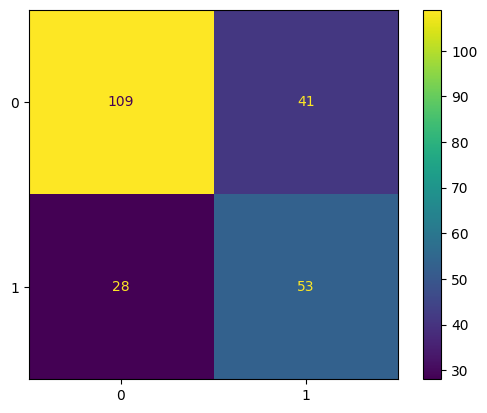

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [ ]:
#recall
# tp/(tp+fn)

53/(53+28)

0.654320987654321

In [ ]:
import torch.optim as optim

optim.SGD([
    {'params': ann.layer_1_connection.parameters(), 'lr': 1e-2},
    {'params': ann.layer_2_connection.parameters(), 'lr': 1e-2},
    {'params': ann.out.parameters()}
], lr=1e-3, momentum=0.9)


SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0

Parameter Group 2
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ExponentialLR

optimizer = optim.SGD(ann.parameters(), lr=0.01, momentum=0.9)
scheduler = ExponentialLR(optimizer, gamma=0.9)

sgd_loss = []
n_epochs = 500

for epoch in range(n_epochs):
    optimizer.zero_grad()
    y_pred = ann.forward(X_train)
    loss = loss_function(y_pred, y_train)
    sgd_loss.append(loss.item())
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 10 == 1:
        print(f'Epoch number: {epoch} with loss {loss}')

Epoch number: 1 with loss 0.6400476694107056
Epoch number: 11 with loss 0.6244677901268005
Epoch number: 21 with loss 0.6148248910903931
Epoch number: 31 with loss 0.6109065413475037
Epoch number: 41 with loss 0.6097469329833984
Epoch number: 51 with loss 0.6093425750732422
Epoch number: 61 with loss 0.6092007160186768
Epoch number: 71 with loss 0.6091510653495789
Epoch number: 81 with loss 0.6091340780258179
Epoch number: 91 with loss 0.6091281175613403
Epoch number: 101 with loss 0.609126091003418
Epoch number: 111 with loss 0.6091253161430359
Epoch number: 121 with loss 0.6091250777244568
Epoch number: 131 with loss 0.609125018119812
Epoch number: 141 with loss 0.609125018119812
Epoch number: 151 with loss 0.609125018119812
Epoch number: 161 with loss 0.609125018119812
Epoch number: 171 with loss 0.609125018119812
Epoch number: 181 with loss 0.609125018119812
Epoch number: 191 with loss 0.609125018119812
Epoch number: 201 with loss 0.609125018119812
Epoch number: 211 with loss 0.609

Adam works by changing learning rate for each weight automatically. It remembers past gradients and also how they change, so it can update weights in a smarter and more stable way. I think it is like a smarter SGD that adjusts itself while training. In the Adam model's lr = 0.001, and the recall score decrease as I increase the learning rate

In the diabetes dataset, SGD model and scheduler did slightly better than Adam. They help lower loss and a bit better accuracy, and scheduler also slowly lowers learning rate. I think this happened because the learning rate schedule helped SGD learn fast at the beginning and then slow down near the end, which made the final tuning better. So overall, in this case SGD with good scheduling worked a bit better.

In [110]:
# extra credit: 
def divisor_function(n): 
    divisors = []
    for i in range(1, n + 1):
        if n % i == 0:
            divisors.append(i)
    
    count = len(divisors)
    
    print("There are " + str(count) + "divisors: " + str(divisors))

divisor_function(5)



There are 2divisors: [1, 5]
